In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


In [2]:
df = pd.read_csv("raw_sales_data.csv")
df.head()

,order_id,order_date,customer_id,product,category,price,quantity,payment_mode,city
0,1001,01-01-2025,CUST001,Protein Powder,Supplements,2500,1,UPI,Bangalore
1,1002,02-01-2025,CUST002,Creatine,Supplements,1800,2,Card,Chennai
2,1003,03-01-2025,CUST003,Pre-Workout,Supplements,2200,1,Cash,Hyderabad
3,1004,04-01-2025,CUST004,Mass Gainer,Supplements,3000,1,UPI,Kochi
4,1005,05-01-2025,CUST005,BCAA,Supplements,1500,3,Card,Coimbatore


In [ ]:
# basic data inspection


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      50 non-null     int64 
 1   order_date    50 non-null     object
 2   customer_id   50 non-null     object
 3   product       50 non-null     object
 4   category      50 non-null     object
 5   price         50 non-null     int64 
 6   quantity      50 non-null     int64 
 7   payment_mode  50 non-null     object
 8   city          50 non-null     object
dtypes: int64(3), object(6)
memory usage: 3.6+ KB


In [13]:
df.isnull().sum()

order_id        0
order_date      0
customer_id     0
product         0
category        0
price           0
quantity        0
payment_mode    0
city            0
dtype: int64

In [25]:
df["total_sales"] = df["price"]* df["quantity"]

In [ ]:
# data cleaning


In [27]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [ ]:
# kpi calculation


In [29]:
total_revenue = "total_sales"
total_revenue = df["total_sales"].sum()
average_order_value = df["total_sales"].mean()
total_orders = df["order_id"].nunique()

top_product = (
    df.groupby("product")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

total_revenue, average_order_value, total_orders, top_product

(158000, 3160.0, 50, 'BCAA')

In [31]:
# sales by product

In [33]:
sales_by_product = df.groupby("product")["total_sales"].sum()
sales_by_product

product
BCAA              45000
Creatine          36000
Mass Gainer       30000
Pre-Workout       22000
Protein Powder    25000
Name: total_sales, dtype: int64

In [ ]:
# sales by city


In [35]:
sales_by_city = df.groupby("city")["total_sales"].sum()
sales_by_city

city
Bangalore     25000
Chennai       36000
Coimbatore    45000
Hyderabad     22000
Kochi         30000
Name: total_sales, dtype: int64

In [ ]:
# visualization product sales

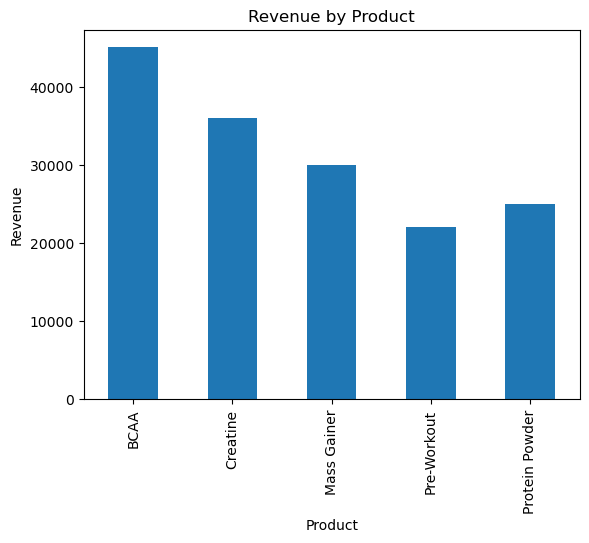

In [37]:
sales_by_product.plot(kind="bar")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# visualization city sales


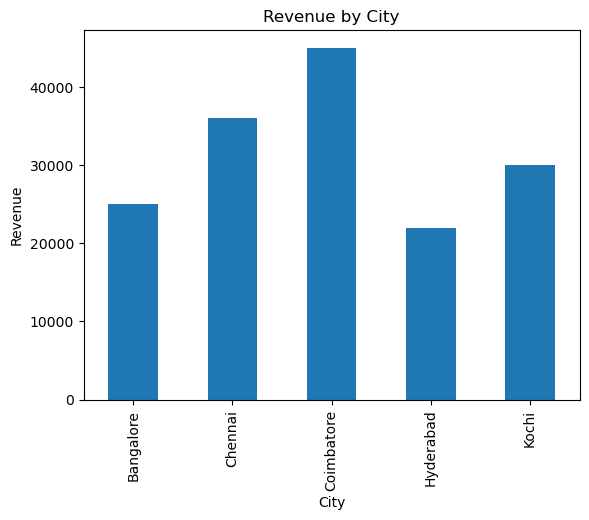

In [39]:
sales_by_city.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# daily sales trend

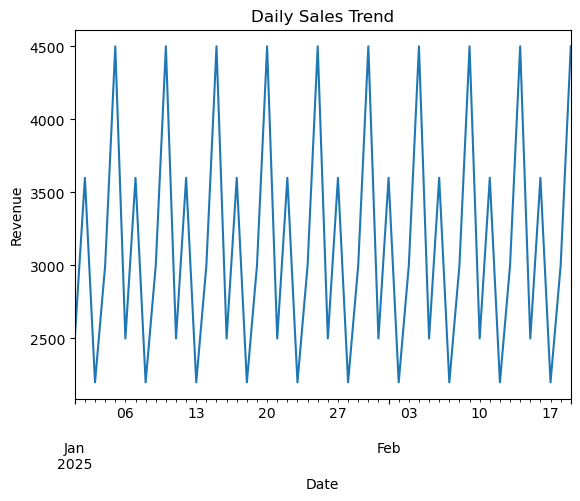

In [41]:
daily_sales = df.groupby("order_date")["total_sales"].sum()

daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# automated excel report


In [47]:
with pd.ExcelWriter(f"sales_report_{report_date}.xlsx") as writer:
    df.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    sales_by_product.to_frame("Revenue").to_excel(writer, sheet_name="Product_Summary")



In [ ]:
# run automation


In [55]:
def generate_sales_report(input_file):
    df = pd.read_csv(input_file)

    # Data validation
    df = df[df["price"] > 0]
    df = df[df["quantity"] > 0]

    # ROBUST date parsing (IMPORTANT FIX)
    df["order_date"] = pd.to_datetime(
        df["order_date"],
        format="mixed",
        dayfirst=True,
        errors="coerce"
    )

    # Drop invalid dates
    df = df.dropna(subset=["order_date"])

    # Feature engineering
    df["total_sales"] = df["price"] * df["quantity"]

    # KPIs
    total_revenue = df["total_sales"].sum()
    avg_order_value = df["total_sales"].mean()
    total_orders = df["order_id"].nunique()

    sales_by_product = df.groupby("product")["total_sales"].sum()

    report_date = datetime.now().strftime("%Y-%m-%d")
    output_file = f"automated_sales_report_{report_date}.xlsx"

    with pd.ExcelWriter(output_file) as writer:
        df.to_excel(writer, index=False, sheet_name="Cleaned_Data")
        sales_by_product.to_frame("Revenue").to_excel(
            writer, sheet_name="Product_Summary"
        )

    return {
        "total_revenue": total_revenue,
        "avg_order_value": avg_order_value,
        "total_orders": total_orders,
        "output_file": output_file
    }

In [57]:
generate_sales_report("raw_sales_data.csv")

{'total_revenue': 158000,
 'avg_order_value': 3160.0,
 'total_orders': 50,
 'output_file': 'automated_sales_report_2026-02-03.xlsx'}